In [1]:
# ==========================================
# BLOCK 1: INGESTION & SCALING
# ==========================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import os

print("Loading Master Dataset for ML Modeling...")
data_path = "../data"
df_master = pd.read_csv(os.path.join(data_path, "final_master_dataset.csv"))

# 1. Hide the Metadata (Strings) from the Algorithm
# We set the ID as the index so it's safe, and we separate the Category string
df_meta = df_master[["customer_unique_id", "Top_Category"]].copy()
df_math = df_master.drop(columns=["Top_Category"]).set_index("customer_unique_id")

print(f"Math features ready for scaling: {df_math.columns.tolist()}")

# 2. Prevent Mathematical Manipulation (Scaling)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_math)

# Convert back to a DataFrame for readability
df_scaled = pd.DataFrame(scaled_data, columns=df_math.columns, index=df_math.index)

# 3. Export the Scaler for the Streamlit App!
# Streamlit will need this exact scaler to transform new, incoming users tomorrow
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
scaler_path = os.path.join(models_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Data successfully scaled. Scaler saved to {scaler_path}")
display(df_scaled.head(3))

Loading Master Dataset for ML Modeling...
Math features ready for scaling: ['Recency', 'Frequency', 'Monetary', 'avg_review_score', 'review_count', 'low_review_flag']
Data successfully scaled. Scaler saved to ../models\scaler.pkl


,Recency,Frequency,Monetary,avg_review_score,review_count,low_review_flag
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.825357,-0.159829,-0.102942,0.667399,-0.122697,-0.386344
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.805697,-0.159829,-0.609806,-0.114297,-0.122697,-0.386344
0000f46a3911fa3c0805444483337064,1.959873,-0.159829,-0.348973,-0.895993,-0.122697,-0.386344


Running the Elbow Method to find optimal K...


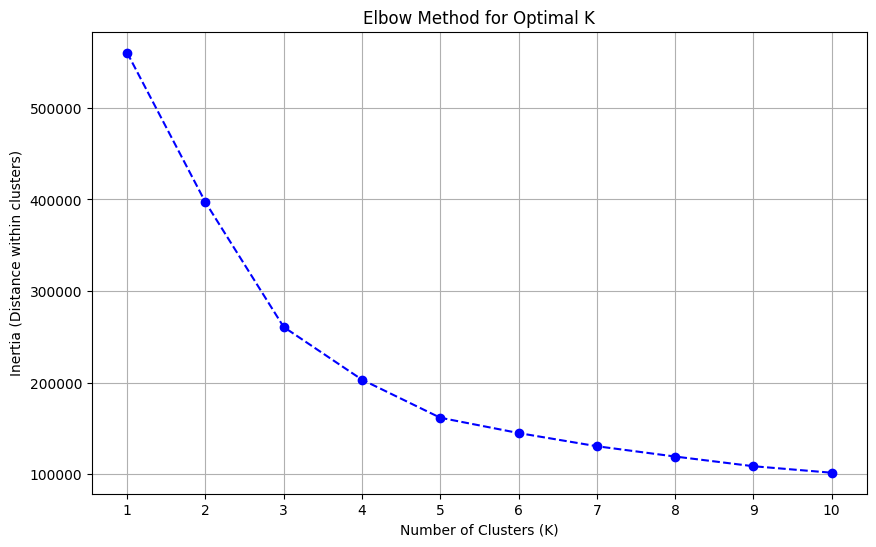

In [2]:
# ==========================================
# BLOCK 2: THE ELBOW METHOD
# ==========================================
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Running the Elbow Method to find optimal K...")

inertia_values = []
k_range = range(1, 11)

# Test K from 1 to 10
for k in k_range:
    # init='k-means++' ensures smart starting points
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Distance within clusters)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [3]:
print("Training final K-Means model with K=4...")

# 1. Train the model using the scaled math data
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
final_kmeans.fit(df_scaled)

# 2. Extract the cluster labels (0, 1, 2, or 3) and attach them to the original Master dataset
# We attach it to df_master so we keep the real money values and text categories!
df_master['Cluster'] = final_kmeans.labels_

# 3. Export the trained model (For Streamlit to use on new data)
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "kmeans_model.pkl")
joblib.dump(final_kmeans, model_path)

# 4. Export the final clustered dataset
data_path = "../data"
output_csv = os.path.join(data_path, "clustered_customers.csv")
df_master.to_csv(output_csv, index=False)

print(f"Model saved to: {model_path}")
print(f"Clustered data saved to: {output_csv}")
display(df_master[['customer_unique_id', 'Top_Category', 'Cluster']].head())

Training final K-Means model with K=4...
Model saved to: ../models\kmeans_model.pkl
Clustered data saved to: ../data\clustered_customers.csv


,customer_unique_id,Top_Category,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,cama_mesa_banho,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,beleza_saude,2
2,0000f46a3911fa3c0805444483337064,papelaria,0
3,0000f6ccb0745a6a4b88665a16c9f078,telefonia,0
4,0004aac84e0df4da2b147fca70cf8255,telefonia,0


In [4]:
# ==========================================
# BLOCK 4: CLUSTER PROFILING (DECODING THE LABELS)
# ==========================================
print("Profiling clusters to determine their business meaning...")

# Group by the cluster label and calculate the mean for our core math columns
cluster_profile = df_master.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'avg_review_score': 'mean',
    'customer_unique_id': 'count' # Count how many humans are in each group
}).rename(columns={'customer_unique_id': 'Total_Customers'})

# Sort by Monetary value to help us easily spot the VIPs vs. low spenders
cluster_profile = cluster_profile.sort_values(by='Monetary', ascending=False)

print("\n--- AVERAGE STATS PER CLUSTER ---")
display(cluster_profile.round(2))

Profiling clusters to determine their business meaning...

--- AVERAGE STATS PER CLUSTER ---


,Recency,Frequency,Monetary,avg_review_score,Total_Customers
Cluster,,,,,
1,220.53,2.11,313.53,4.21,2770
3,236.93,1.00,188.01,1.24,11590
0,388.67,1.00,158.51,4.56,33940
2,125.74,1.00,155.25,4.58,45058
